In [1]:
import os
import pandas as pd
import numpy as np
from trxtools import metaprofiles as meta
from trxtools import methods as ttm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl
import seaborn as sns

Load BigWig files and tRNA BED reference

In [ ]:
bw_folder = '../04a_BigWig_umitools/'
bigwig_plus = [bw_folder + file for file in os.listdir(bw_folder) if file.endswith("umitools_CPM_fwd.bw")
and "Cyclon" in file]
bigwig_minus = [bw_folder + file for file in os.listdir(bw_folder) if file.endswith("umitools_CPM_rev.bw")
and "Cyclon" in file]
bed_trna = pd.read_csv("../references/hg38-tRNAs.bed", sep='\t', header=None)

In [3]:
# Drop this contig from BED as it's not included in the BigWigs
bed_trna = bed_trna[bed_trna[0] !='chr1_KI270713v1_random']
bed_introns = bed_trna[~bed_trna[11].str.split(",", expand=True)[2].isnull()]
bed_nointrons= bed_trna[bed_trna[11].str.split(",", expand=True)[2].isnull()]

Set flanks around tRNA genes - the gtRNAdb BED file contains mature genes.

In [4]:
flank_5=50
flank_3=100

## tRNA expression heatmap

A heatmap makes it easy to compare expression levels of tRNAs between samples.

Using `regionScore()` we can extract and aggreegate (sum by default) coverage data on a set of features from multiple BigWig files: 

In [5]:
df02 = meta.regionScore(
    bigwig_plus, bigwig_minus, bed_trna,
    agg_type='sum', flank_5=flank_5, flank_3=flank_3,
)
df02 = ttm.cleanNames(df02, ['../04a_BigWig_umitools/AG241010_','_none_120mJ_','_all_dedup_CPM_plus.bw'])

Text(0.5, 0.98, 'Flanked tRNA gene expression')

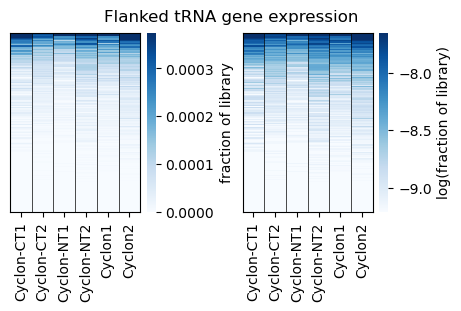

In [6]:
plotdata = df02.copy()
# Sort by mean expression across samples
plotdata['mean'] = plotdata.mean(1)
plotdata = plotdata.sort_values('mean', ascending=False).drop(columns='mean')
fig, axs = plt.subplots(1,2, figsize=(4.5,3), sharey=True, layout='constrained')
sns.heatmap(plotdata, cmap='Blues', robust=True, vmin=0, ax=axs[0], cbar_kws={'label': 'fraction of library'})
sns.heatmap(np.log(plotdata.add(0.0001)), cmap='Blues', robust=True, ax=axs[1], cbar_kws={'label': 'log(fraction of library)'})
for ax in axs:
    ax.set(ylabel=None)
    for i in range(0,6):
        ax.axvline(i, color='black', linewidth=0.5)
    ax.tick_params(labelleft=False, left=False)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
    
fig.suptitle("Flanked tRNA gene expression")

## tRNA metagene profiles

### tRNAs without introns

Here we're using `getMultipleMatrices()` to extract data for multiple genes from multiple BigWig files. We can align the genes at their 5' or 3' ends:

In [7]:
# align at 5'end
mm01 = meta.getMultipleMatrices(
    bigwig_plus,
    bigwig_minus,
    bed_nointrons,
    flank_5=flank_5,
    flank_3=flank_3,
    fill_na=True,
    pseudocounts=0.0001,
    normalize_libsize=True
)

# align at 3'end
mm02_3end = meta.getMultipleMatrices(
    bigwig_plus,
    bigwig_minus,
    bed_nointrons,
    align_3end=True,
    flank_5=flank_5,
    flank_3=flank_3,
    fill_na=True,
    pseudocounts=0.0001,
    normalize_libsize=True
)

We can then compute a metagene profile with `metaprofile()`. The score of each position is aggregated between all genes in a manner dependent on `agg_type` (mean, median or sum).


Text(0.5, 0.98, 'Library normalized tRNA metaprofiles (no introns)')

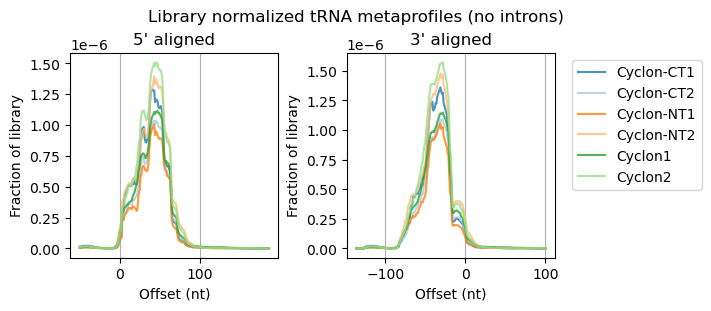

In [8]:
mp01 = meta.metaprofile(mm01, agg_type='mean', normalize_internal=False)
mp01 = ttm.cleanNames(mp01, ['../04a_BigWig_umitools/AG241010_','_none_120mJ_','_all_dedup_CPM_plus.bw'])
mp02 = meta.metaprofile(mm02_3end, agg_type='mean', normalize_internal=False)
mp02 = ttm.cleanNames(mp02, ['../04a_BigWig_umitools/AG241010_','_none_120mJ_','_all_dedup_CPM_plus.bw'])

fig, axes = plt.subplots(1,2, figsize=(7,3), layout='constrained')
colors = mpl.colormaps['tab20'].colors

mp01.plot(color=colors, alpha=0.8, ax=axes[0])
axes[0].set_title("5' aligned")
axes[0].legend().remove()

mp02.plot(color=colors, alpha=0.8, ax=axes[1])
axes[1].set_title("3' aligned")
axes[1].legend(bbox_to_anchor=(1.05, 1))

for ax in axes:
    ax.set_xlabel("Offset (nt)")
    ax.set_ylabel("Fraction of library")
    ax.grid(axis='x')
plt.suptitle("Library normalized tRNA metaprofiles (no introns)")

With `normalize_internal` set to true we can normalize the data internally to the maximum value. This makes it easier to compare the shapes of different profiles regardless of the relative expression levels of selected features in different libraries.

Text(0.5, 0.98, 'Internally normalized tRNA metaprofiles (no introns)')

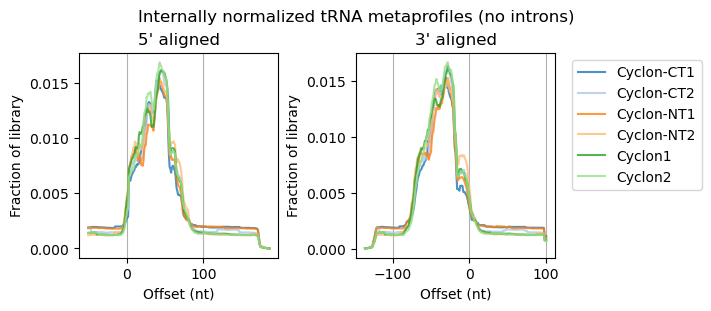

In [9]:
mp01_n = meta.metaprofile(mm01, agg_type='mean', normalize_internal=True)
mp01_n = ttm.cleanNames(mp01_n, ['../04a_BigWig_umitools/AG241010_','_none_120mJ_','_all_dedup_CPM_plus.bw'])
mp02_n = meta.metaprofile(mm02_3end, agg_type='mean', normalize_internal=True)
mp02_n = ttm.cleanNames(mp02_n, ['../04a_BigWig_umitools/AG241010_','_none_120mJ_','_all_dedup_CPM_plus.bw'])

fig, axes = plt.subplots(1,2, figsize=(7,3), layout='constrained')
colors = mpl.colormaps['tab20'].colors

mp01_n.plot(color=colors, alpha=0.8, ax=axes[0])
axes[0].set_title("5' aligned")
axes[0].legend().remove()

mp02_n.plot(color=colors, alpha=0.8, ax=axes[1])
axes[1].set_title("3' aligned")
axes[1].legend(bbox_to_anchor=(1.05, 1))

for ax in axes:
    ax.set_xlabel("Offset (nt)")
    ax.set_ylabel("Fraction of library")
    ax.grid(axis='x')
plt.suptitle("Internally normalized tRNA metaprofiles (no introns)")

### tRNAs with introns

Keep in mind that tRNA introns differ in length, making the profiles harder to interpret when aligned to 3' end.

In [ ]:
# align at 5'end
mm03 = meta.getMultipleMatrices(
    bigwig_plus,
    bigwig_minus,
    bed_introns,
    flank_5=flank_5,
    flank_3=flank_3,
    fill_na=True,
    pseudocounts=0.0001,
    normalize_libsize=True
)

Text(0.5, 0.98, 'Library normalized tRNA metaprofiles (with introns)')

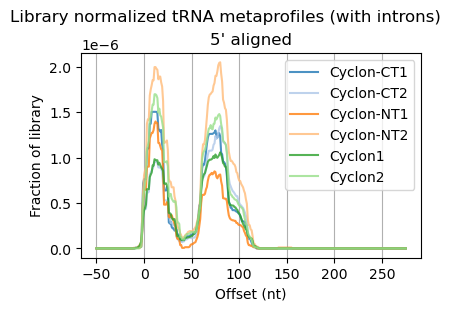

In [18]:
mp03 = meta.metaprofile(mm03, agg_type='mean', normalize_internal=False)
mp03 = ttm.cleanNames(mp03, ['../04a_BigWig_umitools/AG241010_','_none_120mJ_','_all_dedup_CPM_plus.bw'])

fig, ax = plt.subplots(1,1, figsize=(4,3), layout='constrained')
colors = mpl.colormaps['tab20'].colors

mp03.plot(color=colors, alpha=0.8, ax=ax)
ax.set_title("5' aligned")


ax.set_xlabel("Offset (nt)")
ax.set_ylabel("Fraction of library")
ax.grid(axis='x')
plt.suptitle("Library normalized tRNA metaprofiles (with introns)")

Text(0.5, 0.98, 'Internally normalized tRNA metaprofiles (with introns)')

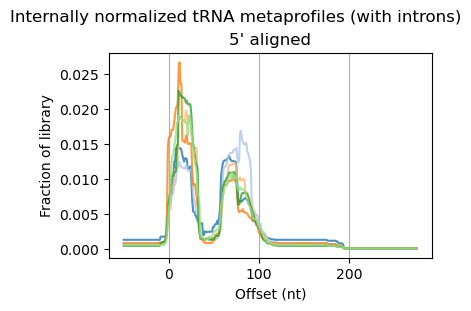

In [20]:
mp03_n = meta.metaprofile(mm03, agg_type='mean', normalize_internal=True)
mp03_n = ttm.cleanNames(mp03_n, ['../04a_BigWig_umitools/AG241010_','_none_120mJ_','_all_dedup_CPM_plus.bw'])

fig, ax = plt.subplots(1,1, figsize=(4,3), layout='constrained')
colors = mpl.colormaps['tab20'].colors

mp03_n.plot(color=colors, alpha=0.8, ax=ax)
ax.set_title("5' aligned")
ax.legend().remove()

ax.set_xlabel("Offset (nt)")
ax.set_ylabel("Fraction of library")
ax.grid(axis='x')
plt.suptitle("Internally normalized tRNA metaprofiles (with introns)")